# Lecture 3 - Shallow Neural Networks
## Lab Notebook · Deep Learning · UCU

---

### Overview
In Notebook 1, we built **linear models** for regression and classification. While useful, linear models can only represent linear relationships — a fundamental limitation for real-world data.

In this notebook, we take the next step: **shallow neural networks**. By adding a single hidden layer with a nonlinear activation function, we unlock the ability to approximate arbitrarily complex functions. The **Universal Approximation Theorem** guarantees that, with enough hidden units, a shallow network can get arbitrarily close to any continuous function.

By the end of this notebook, you will:
- Visualize how **ReLU activations** create piecewise linear functions — the "joints" from Lecture 3
- Implement and compare **activation functions** (ReLU, Leaky ReLU, Sigmoid, Tanh)
- Build a **shallow neural network** using `nn.Module`
- Train it on **FashionMNIST** and compare against the linear baseline from Notebook 1

### Useful References

- [PyTorch `nn.Module` documentation](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)
- [PyTorch activation functions](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)
- [FashionMNIST dataset](https://github.com/zalandoresearch/fashion-mnist)
- [UCU Deep Learning — Lecture 3 notes](../../lectures/lecture%203/notes.md)
- *Understanding Deep Learning* — Prince (2023), Chapter 3

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4, C5 = '#19326E', '#50ACB0', '#CD742A', '#A3477F', '#907FAB'

Using device: cpu


In [2]:
# Load FashionMNIST — downloading now so it's ready when we need it
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Image shape      : {train_dataset[0][0].shape}  →  flattened: {28*28} features")

100%|██████████| 26.4M/26.4M [00:17<00:00, 1.48MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 118kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 972kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.52MB/s]

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])  →  flattened: 784 features


---

## 1. From Lines to Pieces: Piecewise Linear Intuition

Before tackling FashionMNIST, let's build intuition with a simple 1D example.

A linear model can only draw a straight line. A shallow neural network with ReLU activations produces a **piecewise linear function** — a series of connected line segments. Each hidden unit contributes one **"joint"** (a kink) in the output. With $D$ hidden units you get at most $D+1$ linear regions. More hidden units → more joints → better approximation of curved shapes.

The cell below shows a linear model trying (and failing) to fit $\sin(x)$. Your task is to build a shallow network that does better.

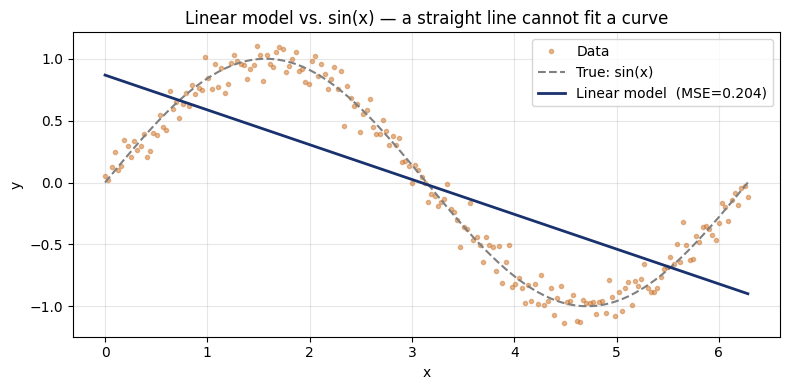

In [3]:
# Generate 1D nonlinear data
x_np = np.linspace(0, 2 * np.pi, 200).astype(np.float32)
y_np = (np.sin(x_np) + 0.1 * np.random.randn(200)).astype(np.float32)

x_t = torch.FloatTensor(x_np).unsqueeze(1)   # shape (200, 1)
y_t = torch.FloatTensor(y_np).unsqueeze(1)   # shape (200, 1)

# Train a linear model
linear_1d = nn.Linear(1, 1)
opt = optim.Adam(linear_1d.parameters(), lr=0.01)
for _ in range(1000):
    opt.zero_grad()
    nn.MSELoss()(linear_1d(x_t), y_t).backward()
    opt.step()

y_linear = linear_1d(x_t).detach().numpy()
linear_1d_mse = nn.MSELoss()(linear_1d(x_t), y_t).item()

plt.figure(figsize=(8, 4))
plt.plot(x_np, y_np, 'o', color=C3, markersize=3, alpha=0.5, label='Data')
plt.plot(x_np, np.sin(x_np), '--', color='gray', linewidth=1.5, label='True: sin(x)')
plt.plot(x_np, y_linear, color=C1, linewidth=2, label=f'Linear model  (MSE={linear_1d_mse:.3f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Linear model vs. sin(x) — a straight line cannot fit a curve')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

### Exercise 1.1 — Build `ShallowNet1D`

Complete the `ShallowNet1D` class below. The architecture should be:

$$\text{Input}(1) \xrightarrow{\text{Linear}} \text{Hidden}(D,\; \text{ReLU}) \xrightarrow{\text{Linear}} \text{Output}(1)$$

No activation on the output — this is a **regression** network.

> **Tip:** Use `nn.Sequential` with `nn.Linear` and `nn.ReLU`.

In [ ]:
class ShallowNet1D(nn.Module):
    def __init__(self, D):
        """
        Shallow network: Input(1) -> Hidden(D, ReLU) -> Output(1)
        Args:
            D: number of hidden units
        """
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError()

    def forward(self, x):
        # YOUR CODE HERE
        raise NotImplementedError()


def train_1d(model, x_t, y_t, lr=0.01, epochs=2000):
    """Train model with MSE loss and Adam optimizer. Returns the trained model."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(epochs):
        optimizer.zero_grad()
        criterion(model(x_t), y_t).backward()
        optimizer.step()
    return model

In [ ]:
# Train and visualize for D = 3, 10, 50
D_values_1d = [3, 10, 50]
colors_1d   = [C2, C4, C1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, D, color in zip(axes, D_values_1d, colors_1d):
    model = train_1d(ShallowNet1D(D), x_t, y_t)
    y_pred = model(x_t).detach().numpy()
    mse = nn.MSELoss()(model(x_t), y_t).item()

    ax.plot(x_np, y_np, 'o', color=C3, markersize=3, alpha=0.4)
    ax.plot(x_np, np.sin(x_np), '--', color='gray', linewidth=1.5, label='True')
    ax.plot(x_np, y_pred, color=color, linewidth=2, label=f'D={D}')
    ax.set_title(f'D={D} hidden units  |  MSE={mse:.4f}')
    ax.set_xlabel('x'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Shallow Network Approximation of sin(x)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Question 1.1** — Looking at the three plots above:

1. How does the output shape change as $D$ increases? What do you notice about the number of "kinks" in the predicted curve? Analyse each image
2. What is the maximum amount of linear regions that can be created with $D=3$ hidden units?


*Your answer here:*

### Exercise 1.2 — Observing Overfitting with Very Large D

So far, more hidden units always helped. But what happens when $D$ is *too* large?

A model with far more parameters than data points can **memorize** the training samples — fitting the noise instead of the underlying pattern. This is called **overfitting**. To make it visible, we use a sparse version of the data (25 points, with higher noise).

1. A well-fitted model (`D=20`) is already trained for you.
2. Train a second model with a **very large** `D` (try $D \geq 500$) for enough epochs to force overfitting.
3. Observe the difference in the provided plot.

> **Hint:** More epochs are needed to overfit — try `epochs=3000`.

In [ ]:
# Sparse, noisy dataset — fewer points make overfitting more dramatic
np.random.seed(0)
x_sparse    = np.linspace(0, 2 * np.pi, 25).astype(np.float32)
y_sparse    = (np.sin(x_sparse) + 0.2 * np.random.randn(25)).astype(np.float32)
x_sparse_t  = torch.FloatTensor(x_sparse).unsqueeze(1)
y_sparse_t  = torch.FloatTensor(y_sparse).unsqueeze(1)

# Provided: well-fitted model
model_good = train_1d(ShallowNet1D(20), x_sparse_t, y_sparse_t, epochs=3000)

# YOUR CODE HERE
# 1. Choose a very large D (>= 500)
# 2. Train a model that overfits — use enough epochs
D_large      = ???
model_overfit = ???
raise NotImplementedError()

# Provided: comparison plot
x_plot    = torch.FloatTensor(np.linspace(0, 2 * np.pi, 300).astype(np.float32)).unsqueeze(1)
x_plot_np = x_plot.numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, model, title, color in [
    (axes[0], model_good,   'D=20  —  good fit',        C2),
    (axes[1], model_overfit, f'D={D_large}  —  overfit', C4),
]:
    ax.plot(x_sparse, y_sparse, 'o', color=C3, markersize=7, zorder=3, label='Training data')
    ax.plot(x_plot_np, np.sin(x_plot_np), '--', color='gray', linewidth=1.5, label='True: sin(x)')
    ax.plot(x_plot_np, model(x_plot).detach().numpy(), color=color, linewidth=2, label=title)
    ax.set_title(title, fontsize=11); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(-2.5, 2.5)

plt.suptitle('Good Fit vs. Overfitting — 1D Regression', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## 2. Activation Functions

The activation function is what gives neural networks their power. Without it, stacking linear layers is mathematically equivalent to a single linear transformation — no matter how many layers you add.

From Lecture 3:

| Activation | Formula |
|---|---|
| ReLU | $\max(0, z)$ |
| Leaky ReLU | $\max(\alpha z,\; z)$, typically $\alpha = 0.01$ |
| Sigmoid | $\frac{1}{1 + e^{-z}}$ |
| Tanh | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ |

### Exercise 2.1 — Implement Activation Functions

Implement each function below using NumPy. The plotting code is already provided.

In [ ]:
def relu(z):
    """Rectified Linear Unit: max(0, z)"""
    # YOUR CODE HERE
    raise NotImplementedError()

def leaky_relu(z, alpha=0.01):
    """Leaky ReLU: max(alpha*z, z)"""
    # YOUR CODE HERE
    raise NotImplementedError()

def sigmoid(z):
    """Logistic sigmoid: 1 / (1 + exp(-z))"""
    # YOUR CODE HERE
    raise NotImplementedError()

def tanh_fn(z):
    """Hyperbolic tangent"""
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
funcs = [
    (relu,       'ReLU',       C1),
    (leaky_relu, 'Leaky ReLU', C2),
    (sigmoid,    'Sigmoid',    C3),
    (tanh_fn,    'Tanh',       C4),
]

for ax, (fn, name, color) in zip(axes, funcs):
    ax.plot(z, fn(z), color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('z')
    ax.set_ylim(-1.6, 4.5 if name in ('ReLU', 'Leaky ReLU') else 1.6)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Question 2.1**

1. What would happen if you replaced ReLU with a **linear activation** $a(z) = z$ in `ShallowNet1D`? Would the network still be able to fit $\sin(x)$? Why or why not?
2. ReLU neurons can become **"dead"** — permanently outputting zero and receiving no gradient. Looking at the ReLU plot, explain when and why this happens.

*Your answer here:*

---

## 3. Shallow Neural Network on FashionMNIST

Now let's apply these ideas to a real classification problem. In Notebook 1 (optional section), a **linear classifier** (`nn.Linear(784, 10)`) was trained on FashionMNIST. Adding one hidden layer turns it into a shallow network:

$$\text{Input}(784) \xrightarrow{\text{Linear}} \text{Hidden}(D,\; \text{ReLU}) \xrightarrow{\text{Linear}} \text{Output}(10)$$

This single addition is the key step from Lecture 3. Let's see how much it helps.

### Question 3.1 — Matrix Formulation of Shallow Networks

From the lecture notes (Section 6), the general shallow network maps $\mathbf{x} \in \mathbb{R}^{D_i}$ to $\mathbf{y} \in \mathbb{R}^{D_o}$ through $D$ hidden units using two equations in matrix form:

$$\mathbf{h} = \text{a}[\boldsymbol{\theta}_0 + \boldsymbol{\Theta}\mathbf{x}]$$

$$\mathbf{y} = \boldsymbol{\phi}_0 + \boldsymbol{\Phi}\mathbf{h}$$

For each of the two networks you will implement in this notebook, fill in the dimensions of every symbol in the table and count the total number of parameters.

---

**Part A — `ShallowNet1D` with $D$ hidden units (Section 1)**  
Scalar input $x \in \mathbb{R}$, scalar output $y \in \mathbb{R}$.

| Symbol | Meaning | Dimensions |
|---|---|---|
| $\mathbf{x}$ | Input | |
| $\boldsymbol{\theta}_0$ | Hidden biases | |
| $\boldsymbol{\Theta}$ | Input-to-hidden weights | |
| $\mathbf{h}$ | Hidden activations | |
| $\boldsymbol{\phi}_0$ | Output bias | |
| $\boldsymbol{\Phi}$ | Hidden-to-output weights | |
| $\mathbf{y}$ | Output | |

Total number of parameters (as a formula in $D$): ___

---

**Part B — `ShallowNet` on FashionMNIST with $D$ hidden units (Section 3)**  
Each image is flattened to 784 features; there are 10 output classes.

| Symbol | Meaning | Dimensions |
|---|---|---|
| $\mathbf{x}$ | Flattened image | |
| $\boldsymbol{\theta}_0$ | Hidden biases | |
| $\boldsymbol{\Theta}$ | Input-to-hidden weights | |
| $\mathbf{h}$ | Hidden activations | |
| $\boldsymbol{\phi}_0$ | Output bias | |
| $\boldsymbol{\Phi}$ | Hidden-to-output weights | |
| $\mathbf{y}$ | Class logits | |

Total number of parameters for $D = 256$: ___

---

*Your answers here:*

In [ ]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')
plt.suptitle('FashionMNIST — sample images', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Exercise 3.1 — Define `ShallowNet`

Complete the `ShallowNet` class. It should:
- Accept a 4D input `(batch, 1, 28, 28)` and **flatten it** to `(batch, 784)` inside `forward`
- Apply one hidden layer of size `hidden_dim` with ReLU
- Produce `output_dim` logits (no softmax — `CrossEntropyLoss` handles that)

> **Note:** `output_dim` = 10 for the 10 FashionMNIST classes.

In [ ]:
class ShallowNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError()

    def forward(self, x):
        # Flatten: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        # YOUR CODE HERE
        raise NotImplementedError()

### Exercise 3.2 — Training and Evaluation Loop

Implement `train_epoch` and `evaluate`:

- **`train_epoch`**: one full pass over `loader` in training mode. Returns `(avg_loss, accuracy_pct)`.
- **`evaluate`**: one full pass over `loader` in eval mode (no gradients). Returns `(avg_loss, accuracy_pct)`.

Use `nn.CrossEntropyLoss` and `optimizer` (passed as arguments). Accuracy is the percentage of correctly predicted labels.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        # YOUR CODE HERE
        raise NotImplementedError()
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy %)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            # YOUR CODE HERE
            raise NotImplementedError()
    return total_loss / len(loader), 100. * correct / total

In [ ]:
criterion = nn.CrossEntropyLoss()

# --- Linear baseline ---
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

linear_model = LinearClassifier().to(device)
opt_linear = optim.Adam(linear_model.parameters(), lr=0.001)

print("Training linear baseline...")
for epoch in range(10):
    train_epoch(linear_model, train_loader, opt_linear, criterion, device)
_, linear_test_acc = evaluate(linear_model, test_loader, criterion, device)
print(f"  Linear baseline — test accuracy: {linear_test_acc:.1f}%")

# --- Shallow network (D=256) ---
shallow_model = ShallowNet(784, 256, 10).to(device)
opt_shallow = optim.Adam(shallow_model.parameters(), lr=0.001)

train_losses, train_accs, test_losses, test_accs = [], [], [], []

print("\nTraining shallow network (D=256)...")
for epoch in range(10):
    tr_loss, tr_acc = train_epoch(shallow_model, train_loader, opt_shallow, criterion, device)
    te_loss, te_acc = evaluate(shallow_model, test_loader, criterion, device)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    test_losses.append(te_loss);  test_accs.append(te_acc)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:2d} | Train: {tr_acc:.1f}%  Test: {te_acc:.1f}%")

_, shallow_test_acc = evaluate(shallow_model, test_loader, criterion, device)
print(f"\n{'='*45}")
print(f"  Linear baseline test accuracy : {linear_test_acc:.1f}%")
print(f"  Shallow network test accuracy : {shallow_test_acc:.1f}%")
print(f"  Improvement                   : +{shallow_test_acc - linear_test_acc:.1f}%")

In [ ]:
epochs_range = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, train_losses, color=C1, marker='o', label='Train loss')
axes[0].plot(epochs_range, test_losses,  color=C3, marker='s', linestyle='--', label='Test loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accs, color=C1, marker='o', label='Train accuracy')
axes[1].plot(epochs_range, test_accs,  color=C3, marker='s', linestyle='--', label='Test accuracy')
axes[1].axhline(linear_test_acc, color=C2, linestyle=':', linewidth=2,
                label=f'Linear baseline ({linear_test_acc:.1f}%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy curves'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Shallow Network (D=256) vs. Linear Baseline — FashionMNIST',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Question 3.2**

1. By how much (in percentage points) did the shallow network improve over the linear baseline?
2. Is there a noticeable gap between train and test accuracy? What does this tell us about the model?

*Your answer here:*

### Experiment — How does the number of hidden units affect performance?

The **Universal Approximation Theorem** says that more hidden units means more capacity. But more capacity also means higher risk of overfitting and longer training. Let's verify this empirically.

The cell below trains a shallow network for each $D \in \{16, 64, 256, 512, 1024, 2048, 4096\}$. **This may take a few minutes.**

In [ ]:
D_values = [16, 64, 256, 512, 1024, 2048, 4096]
results   = {}

for D in D_values:
    model = ShallowNet(784, D, 10).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    for _ in range(10):
        train_epoch(model, train_loader, opt, criterion, device)
    _, tr_acc = evaluate(model, train_loader, criterion, device)
    _, te_acc = evaluate(model, test_loader,  criterion, device)
    results[D] = (tr_acc, te_acc)
    print(f"D={D:4d}  |  Train: {tr_acc:.1f}%  |  Test: {te_acc:.1f}%")

# Plot
D_list       = list(results.keys())
train_accs_d = [results[d][0] for d in D_list]
test_accs_d  = [results[d][1] for d in D_list]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(D_list, train_accs_d, 'o-', color=C1, linewidth=2, label='Train accuracy')
ax.plot(D_list, test_accs_d,  's--', color=C3, linewidth=2, label='Test accuracy')
ax.axhline(linear_test_acc, color=C2, linestyle=':', linewidth=2,
           label=f'Linear baseline ({linear_test_acc:.1f}%)')
ax.set_xticks(D_list)
ax.set_xticklabels([str(d) for d in D_list])
ax.set_xlabel('Hidden units D'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs. Network Capacity (FashionMNIST)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Question 3.2**

1. At what value of $D$ does the test accuracy seem to plateau?
2. For large $D$, do you observe a growing gap between train and test accuracy? What does this suggest?

*Your answer here:*

---

## Optional: California Housing — Visualizing Learned Weights

In Notebook 1, you trained a **linear model** on the California Housing dataset. Linear models are directly interpretable: each weight tells you exactly how much a feature affects the prediction.

Shallow networks are harder to interpret, but we can still get intuition from the **first-layer weights** $\boldsymbol{\Theta} \in \mathbb{R}^{D \times D_i}$. Each row is a hidden unit's receptive field over the input features. By averaging the absolute values across all hidden units, we get a rough measure of which features the network relies on most.

In this optional section you will:
1. Train a shallow network on California Housing (regression)
2. Visualize the learned first-layer weights to see which features matter

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32)
feature_names = list(housing.feature_names)

X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t  = torch.FloatTensor(y_tr).unsqueeze(1)
X_te_t  = torch.FloatTensor(X_te)
y_te_t  = torch.FloatTensor(y_te).unsqueeze(1)

reg_train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True)
reg_test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t),  batch_size=256)

print(f"Features : {feature_names}")
print(f"Train    : {X_tr.shape}  |  Test: {X_te.shape}")

### Optional Exercise — `ShallowNetRegression`

Build a regression version of your shallow network:
- Input: `input_dim` features (8 for California Housing)
- Hidden: `hidden_dim` units with ReLU
- Output: **1 unit**, no activation (direct value prediction)

Then train it with **MSE loss**, **Adam** (`lr=0.001`), **64 hidden units**, for **30 epochs**. Print the loss every 10 epochs.

In [ ]:
class ShallowNetRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError()

    def forward(self, x):
        # YOUR CODE HERE
        raise NotImplementedError()


# Train the model
reg_model    = ShallowNetRegression(8, 64).to(device)
opt_reg      = optim.Adam(reg_model.parameters(), lr=0.001)
criterion_reg = nn.MSELoss()

# YOUR CODE HERE: training loop (30 epochs, print loss every 10 epochs)
raise NotImplementedError()

In [ ]:
# First-layer weights: shape (hidden_dim, input_dim)
first_layer_weights = list(reg_model.parameters())[0].detach().cpu().numpy()

# Mean absolute weight per input feature — a proxy for feature importance
mean_abs_weights = np.mean(np.abs(first_layer_weights), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].bar(feature_names, mean_abs_weights, color=C1)
axes[0].set_title('Mean |Weight| per Feature (First Layer)', fontsize=11)
axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Mean |weight|')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap: all hidden-unit weight vectors
im = axes[1].imshow(first_layer_weights, aspect='auto', cmap='RdBu_r')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1].set_ylabel('Hidden unit index')
axes[1].set_title('First-Layer Weight Matrix  (rows = hidden units)', fontsize=11)
plt.colorbar(im, ax=axes[1])

plt.suptitle('Learned First-Layer Weights — California Housing', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Final MSE
reg_model.eval()
with torch.no_grad():
    test_preds = reg_model(X_te_t.to(device)).cpu()
    test_mse   = nn.MSELoss()(test_preds, y_te_t).item()
print(f"Shallow network test MSE: {test_mse:.4f}")
print("\nTop features by mean |weight|:")
for name, w in sorted(zip(feature_names, mean_abs_weights), key=lambda x: -x[1]):
    print(f"  {name:12s}  {w:.4f}")